### What are the most demended skills for the top 5 most popular data roles?

1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Plot initial finidings
4. Calculate skill percentage
5. Plot final findings


In [1]:
#Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading the dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_US=df[df['job_location']=='United States']

In [3]:
df_skills=df_US.explode('job_skills')

In [16]:
df_skills_count=df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count=df_skills_count.reset_index(name='skill_count')
df_skills_count=df_skills_count.sort_values(by='skill_count', ascending=False)
df_skills_count

,job_skills,job_title_short,skill_count
628,python,Data Scientist,3113
822,sql,Data Scientist,2164
655,r,Data Scientist,1882
870,tableau,Data Scientist,940
714,sas,Data Scientist,936
...,...,...,...
964,vue.js,Senior Data Engineer,1
965,watson,Data Engineer,1
968,webex,Data Engineer,1
969,webex,Data Scientist,1


In [20]:
job_titles=df_skills_count['job_title_short'].unique().tolist()
job_titles=sorted(job_titles[:5])
job_titles


['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Senior Data Engineer',
 'Senior Data Scientist']

In [27]:
job_title_count=df_US['job_title_short'].value_counts().reset_index(name='job_total')

In [30]:
df_skills_percentage=pd.merge(df_skills_count,job_title_count, how='left',on='job_title_short')
df_skills_percentage['skill_percentage']=df_skills_percentage['skill_count']/df_skills_percentage['job_total']*100
df_skills_percentage

,job_skills,job_title_short,skill_count,job_total,skill_percentage
0,python,Data Scientist,3113,4319,72.076870
1,sql,Data Scientist,2164,4319,50.104191
2,r,Data Scientist,1882,4319,43.574902
3,tableau,Data Scientist,940,4319,21.764297
4,sas,Data Scientist,936,4319,21.671683
...,...,...,...,...,...
987,vue.js,Senior Data Engineer,1,334,0.299401
988,watson,Data Engineer,1,1334,0.074963
989,webex,Data Engineer,1,1334,0.074963
990,webex,Data Scientist,1,4319,0.023154


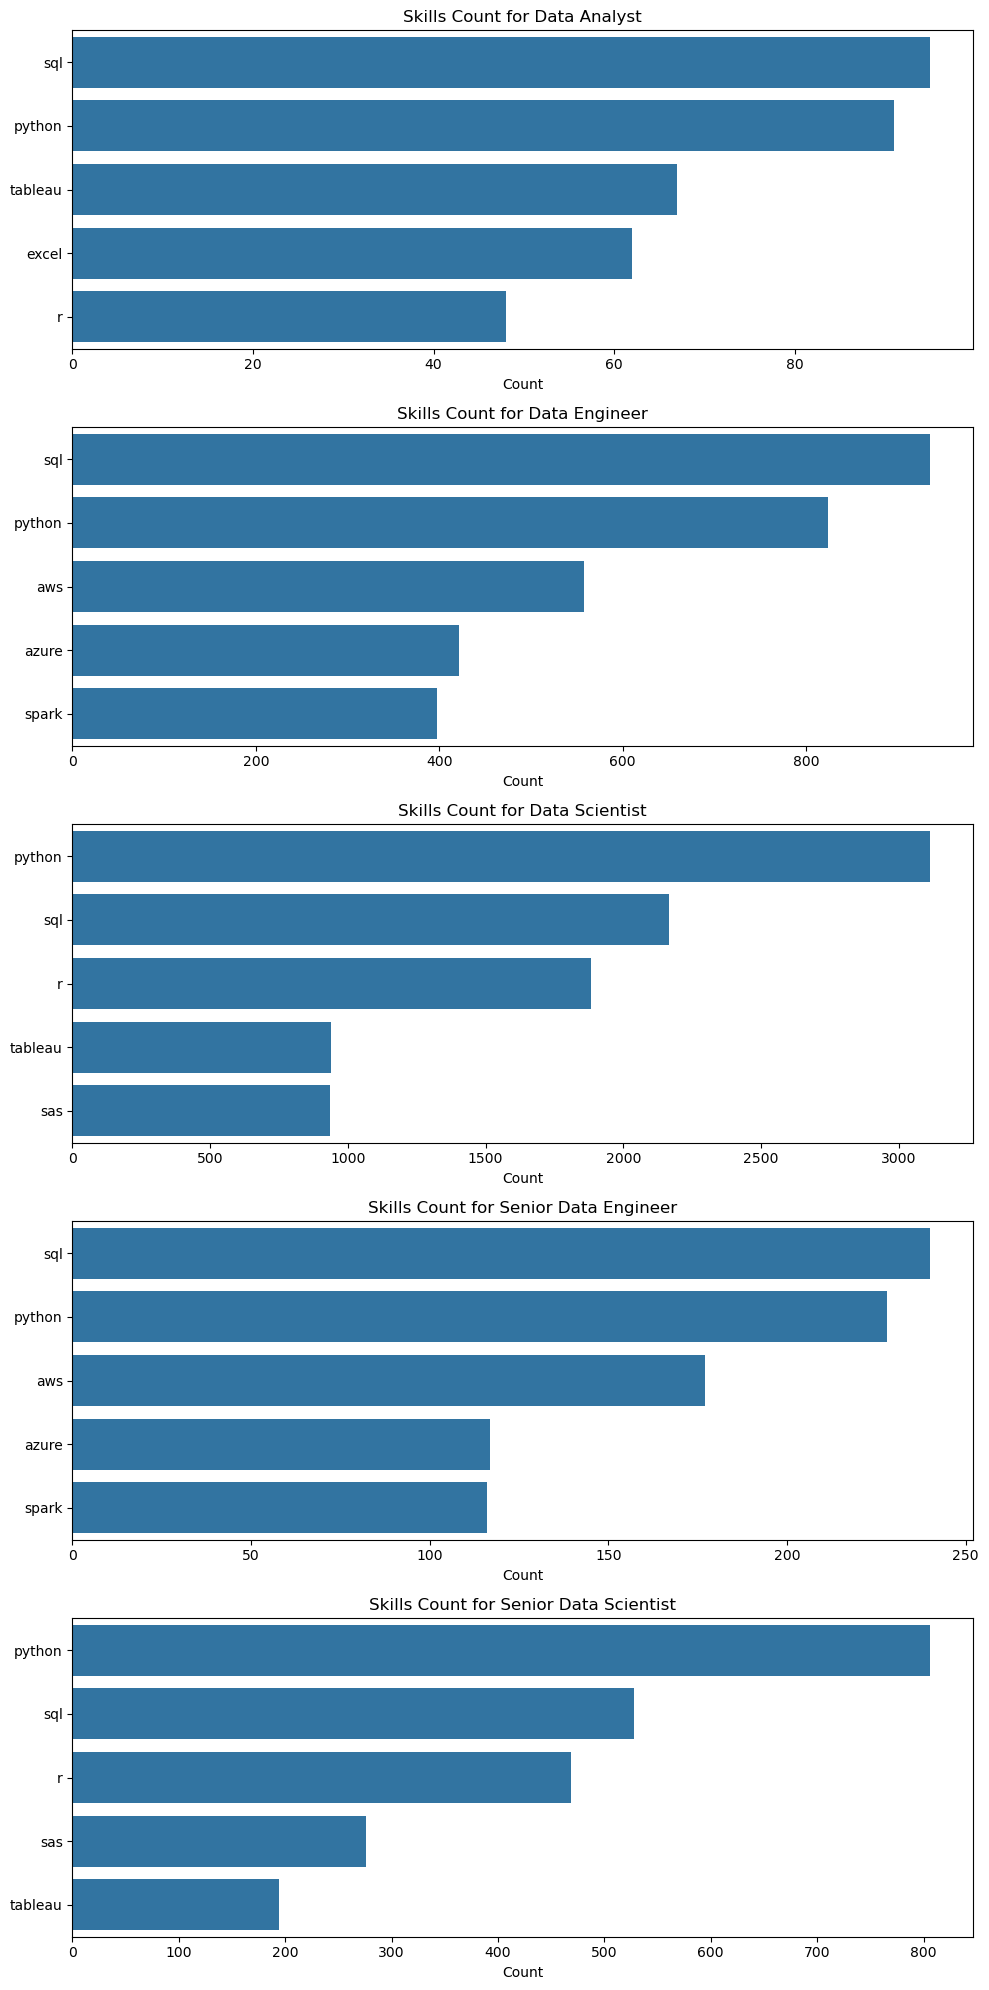

In [24]:
fig, ax=plt.subplots(len(job_titles),1, figsize=(10,20))

for i, job_title in enumerate(job_titles):
    data=df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    sns.barplot(x='skill_count', y='job_skills', data=data, ax=ax[i])
    ax[i].set_title(f'Skills Count for {job_title}')
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('')
plt.tight_layout()
plt.show()

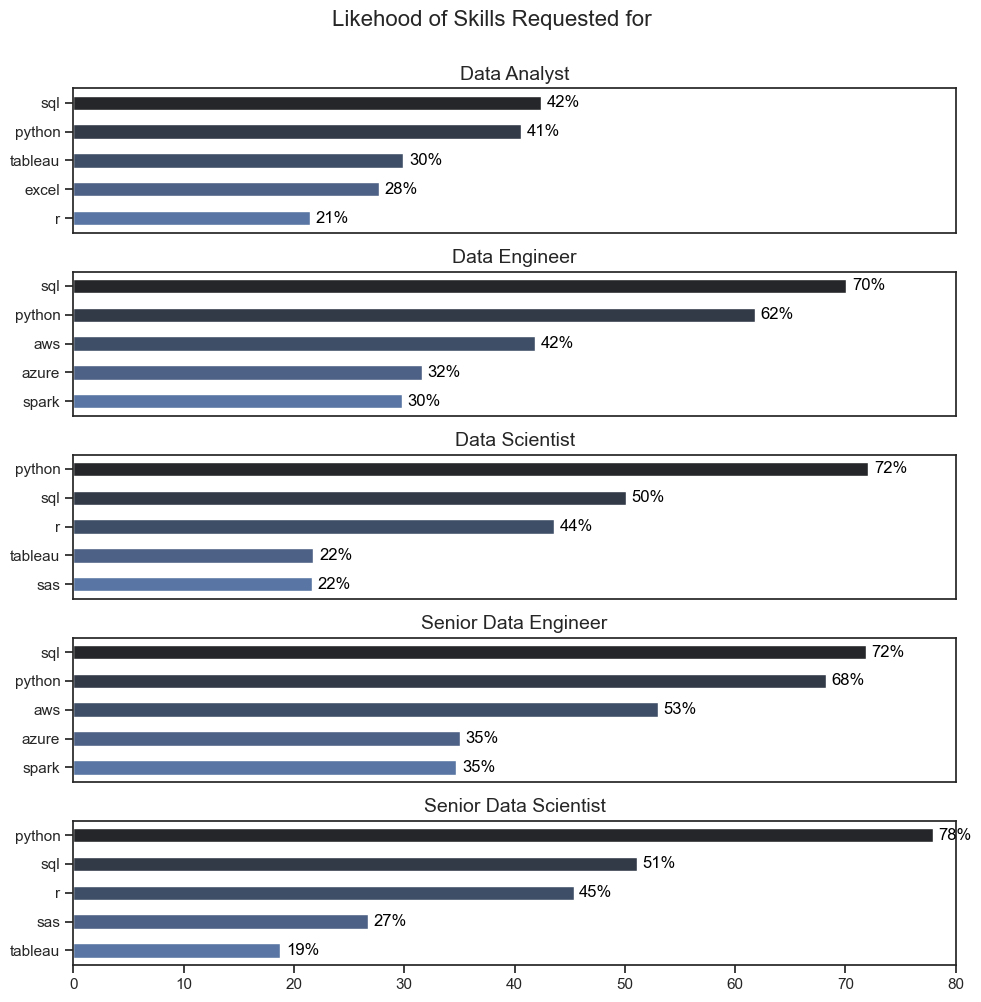

In [69]:
import seaborn as sns
fig, ax=plt.subplots(len(job_titles),1, figsize=(10,10))
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    data=df_skills_percentage[df_skills_percentage['job_title_short']==job_title].head(5)
    sns.barplot(x='skill_percentage', y='job_skills', data=data, ax=ax[i],hue='job_skills', palette='dark:b',width=0.5)
    ax[i].set_title(f'{job_title}',fontsize=14)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,80)

    for n,v in enumerate(data['skill_percentage']):
        ax[i].text(v+0.5, n, f'{v:.0f}%', color='black', va='center')
    if i != len(job_titles)-1:
        ax[i].set_xticks([])
fig.suptitle('Likehood of Skills Requested for',fontsize=16,y=1)

plt.tight_layout(h_pad=1)
plt.show()